## Imports complets

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                               roc_curve, auc, precision_recall_curve, f1_score, recall_score, precision_score)
import joblib
import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Bibliothèques chargées")

Bibliothèques chargées


## Chargement et préparation

In [24]:
df = pd.read_csv("../data/raw/predictive_maintenance.csv")
df_model = df.drop(columns=['UDI', 'Product ID', 'Failure Type'])

encodeur_type = LabelEncoder()
df_model['Type'] = encodeur_type.fit_transform(df_model['Type'])

X = df_model.drop(columns=['Target'])
y = df_model['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")
print(f"Pannes dans train : {y_train.sum()} | Pannes dans test : {y_test.sum()}")

Train : 8000 lignes | Test : 2000 lignes
Pannes dans train : 271 | Pannes dans test : 68


## Normalisation des données

In [25]:
# Certains modèles (SVM, KNN, Régression logistique) sont sensibles à l'échelle des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Normalisation effectuée")
print(f"Moyenne avant : {X_train.mean().values[:3]}")
print(f"Moyenne après : {X_train_scaled.mean(axis=0)[:3]}")

Normalisation effectuée
Moyenne avant : [  1.199     300.00545   310.0060625]
Moyenne après : [-8.88178420e-17  1.75859327e-15  1.05346842e-14]


## Rééquilibrage avec SMOTE

In [26]:
# SMOTE crée des exemples synthétiques de la classe minoritaire (pannes)
# pour que le modèle apprenne mieux à les reconnaître, sans dupliquer bêtement

print("Avant SMOTE :")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\nAprès SMOTE :")
print(pd.Series(y_train_smote).value_counts())

Avant SMOTE :
Target
0    7729
1     271
Name: count, dtype: int64

Après SMOTE :
Target
0    7729
1    7729
Name: count, dtype: int64


## Visualisation de l'effet de SMOTE

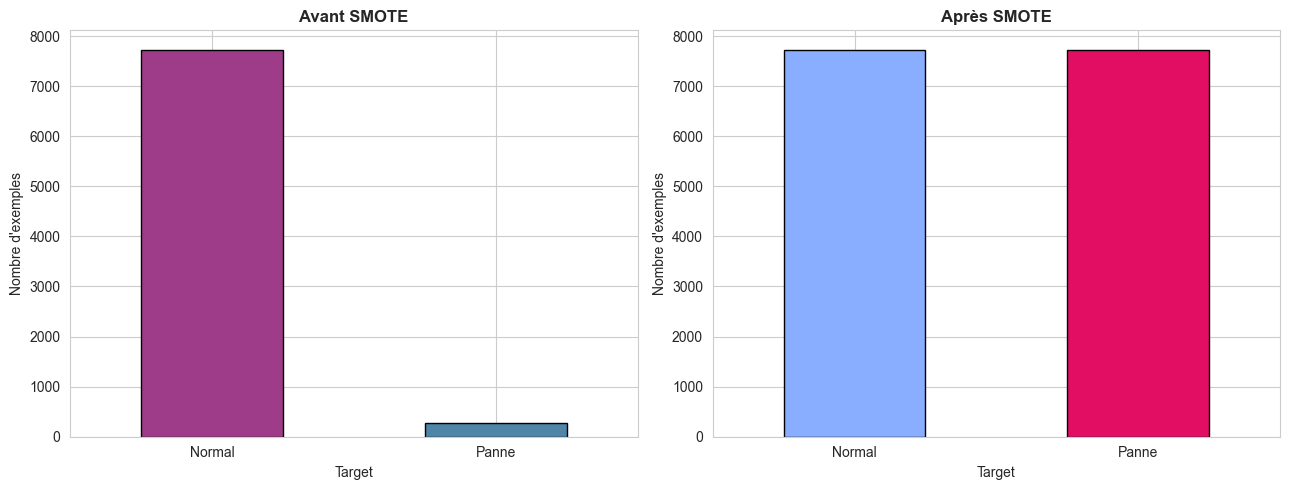

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

y_train.value_counts().sort_index().plot(kind='bar', ax=axes[0], 
                                            color=["#9f3c8a", "#4f85a7"], edgecolor='black')
axes[0].set_title("Avant SMOTE", fontweight='bold')
axes[0].set_xticklabels(['Normal', 'Panne'], rotation=0)
axes[0].set_ylabel("Nombre d'exemples")

pd.Series(y_train_smote).value_counts().sort_index().plot(kind='bar', ax=axes[1], 
                                                              color=["#89adff", "#e20e63"], edgecolor='black')
axes[1].set_title("Après SMOTE", fontweight='bold')
axes[1].set_xticklabels(['Normal', 'Panne'], rotation=0)
axes[1].set_ylabel("Nombre d'exemples")

plt.tight_layout()
plt.savefig("../docs/effet_smote.png", dpi=150, bbox_inches='tight')
plt.show()

## Définition des modèles à comparer

In [28]:
modeles = {
    "Régression Logistique": LogisticRegression(random_state=42, max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Arbre de Décision": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42)
}

print(f"{len(modeles)} modèles à comparer")

6 modèles à comparer


## Entraînement et évaluation de tous les modèles

In [29]:
resultats = []

for nom, modele in modeles.items():
    # Entraînement sur les données rééquilibrées par SMOTE
    modele.fit(X_train_smote, y_train_smote)
    
    # Prédiction sur le vrai jeu de test (jamais rééquilibré, pour rester réaliste)
    y_pred = modele.predict(X_test_scaled)
    
    resultats.append({
        "Modèle": nom,
        "Accuracy": (y_pred == y_test).mean(),
        "Precision (Panne)": precision_score(y_test, y_pred),
        "Recall (Panne)": recall_score(y_test, y_pred),
        "F1-score (Panne)": f1_score(y_test, y_pred)
    })
    
    print(f"✓ {nom} entraîné")

df_resultats = pd.DataFrame(resultats).sort_values("F1-score (Panne)", ascending=False)
df_resultats

✓ Régression Logistique entraîné
✓ KNN entraîné
✓ Arbre de Décision entraîné
✓ Random Forest entraîné
✓ Gradient Boosting entraîné
✓ SVM entraîné


,Modèle,Accuracy,Precision (Panne),Recall (Panne),F1-score (Panne)
3,Random Forest,0.9585,0.439024,0.794118,0.565445
4,Gradient Boosting,0.9465,0.377358,0.882353,0.528634
2,Arbre de Décision,0.9405,0.341615,0.808824,0.480349
1,KNN,0.9320,0.302326,0.764706,0.433333
5,SVM,0.9200,0.285047,0.897059,0.432624
0,Régression Logistique,0.8230,0.142500,0.838235,0.243590


## Visualisation comparative des modèles


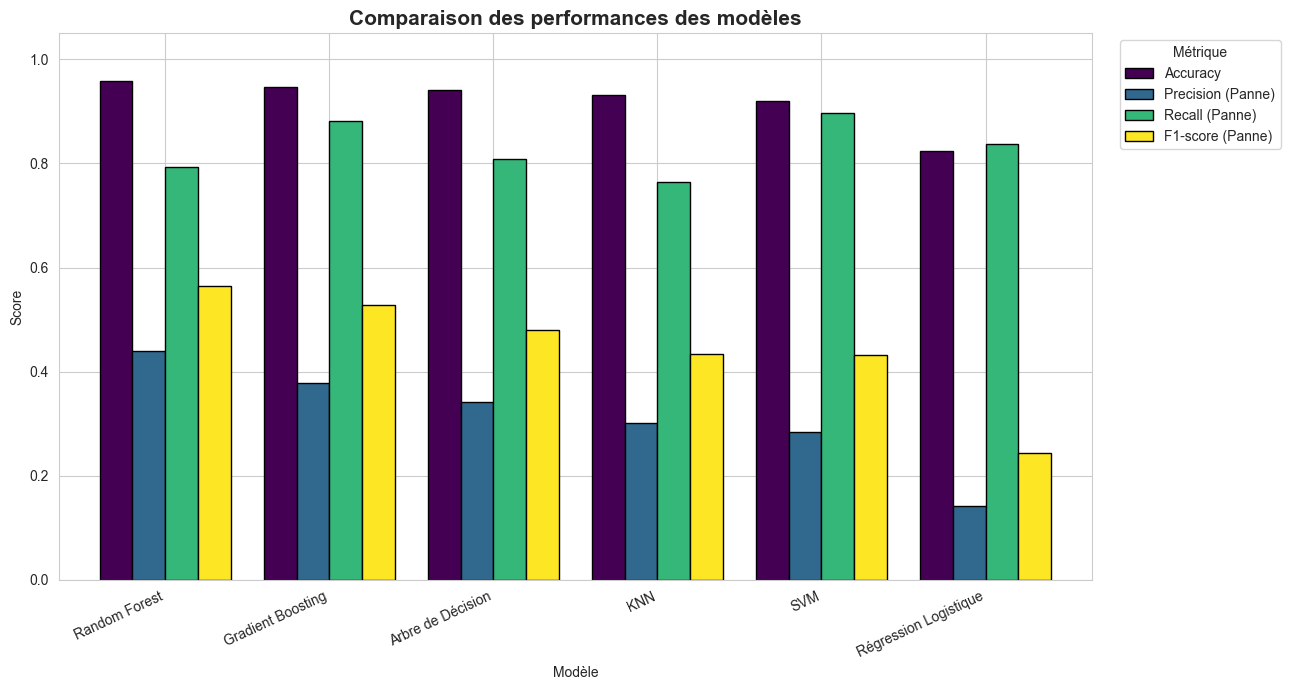

In [30]:
fig, ax = plt.subplots(figsize=(13, 7))

df_plot = df_resultats.set_index("Modèle")[["Accuracy", "Precision (Panne)", "Recall (Panne)", "F1-score (Panne)"]]
df_plot.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black', width=0.8)

plt.title("Comparaison des performances des modèles", fontsize=15, fontweight='bold')
plt.ylabel("Score")
plt.xticks(rotation=25, ha='right')
plt.legend(title="Métrique", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("../docs/comparaison_modeles.png", dpi=150, bbox_inches='tight')
plt.show()

## Courbes ROC de tous les modèles

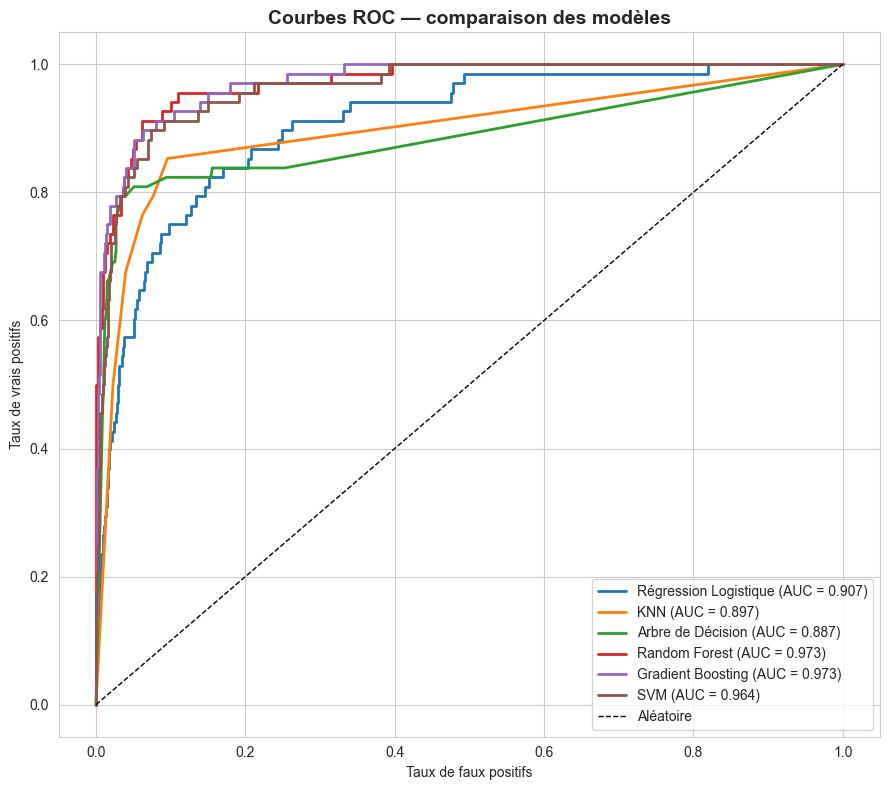

In [31]:
plt.figure(figsize=(9, 8))

for nom, modele in modeles.items():
    y_proba = modele.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{nom} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label="Aléatoire")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC — comparaison des modèles", fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("../docs/courbes_roc.png", dpi=150, bbox_inches='tight')
plt.show()

## Sélection et optimisation du meilleur modèle (GridSearch)

In [32]:
# D'après les résultats précédents, Random Forest et Gradient Boosting sont généralement les meilleurs
# On optimise ici Random Forest avec GridSearchCV pour aller chercher les meilleurs hyperparamètres

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 12, 16, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5),
    scoring='f1',  # on optimise le F1-score de la classe Panne, pas l'accuracy
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_smote, y_train_smote)

print("Meilleurs paramètres :", grid_search.best_params_)
print(f"Meilleur score F1 (cross-validation) : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Meilleurs paramètres : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Meilleur score F1 (cross-validation) : 0.9835


## Évaluation du modèle final optimisé

In [33]:
meilleur_modele = grid_search.best_estimator_
y_pred_final = meilleur_modele.predict(X_test_scaled)

print("=== Rapport de classification du modèle final optimisé ===")
print(classification_report(y_test, y_pred_final, target_names=['Normal', 'Panne']))

=== Rapport de classification du modèle final optimisé ===
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.98      1932
       Panne       0.55      0.78      0.64        68

    accuracy                           0.97      2000
   macro avg       0.77      0.88      0.81      2000
weighted avg       0.98      0.97      0.97      2000



## Ajustement du seuil de décision

In [34]:
# Par défaut, un modèle classe "Panne" si probabilité > 0.5
# On va tester différents seuils pour trouver le meilleur équilibre precision/recall

y_proba_final = meilleur_modele.predict_proba(X_test_scaled)[:, 1]

precisions, recalls, seuils = precision_recall_curve(y_test, y_proba_final)

# Calcul du F1-score pour chaque seuil testé
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
meilleur_seuil_idx = np.argmax(f1_scores)
meilleur_seuil = seuils[meilleur_seuil_idx]

print(f"Seuil par défaut : 0.5")
print(f"Meilleur seuil trouvé : {meilleur_seuil:.3f}")
print(f"F1-score à ce seuil : {f1_scores[meilleur_seuil_idx]:.3f}")
print(f"Precision à ce seuil : {precisions[meilleur_seuil_idx]:.3f}")
print(f"Recall à ce seuil : {recalls[meilleur_seuil_idx]:.3f}")

Seuil par défaut : 0.5
Meilleur seuil trouvé : 0.710
F1-score à ce seuil : 0.718
Precision à ce seuil : 0.746
Recall à ce seuil : 0.691


## Visualisation precision/recall selon le seuil

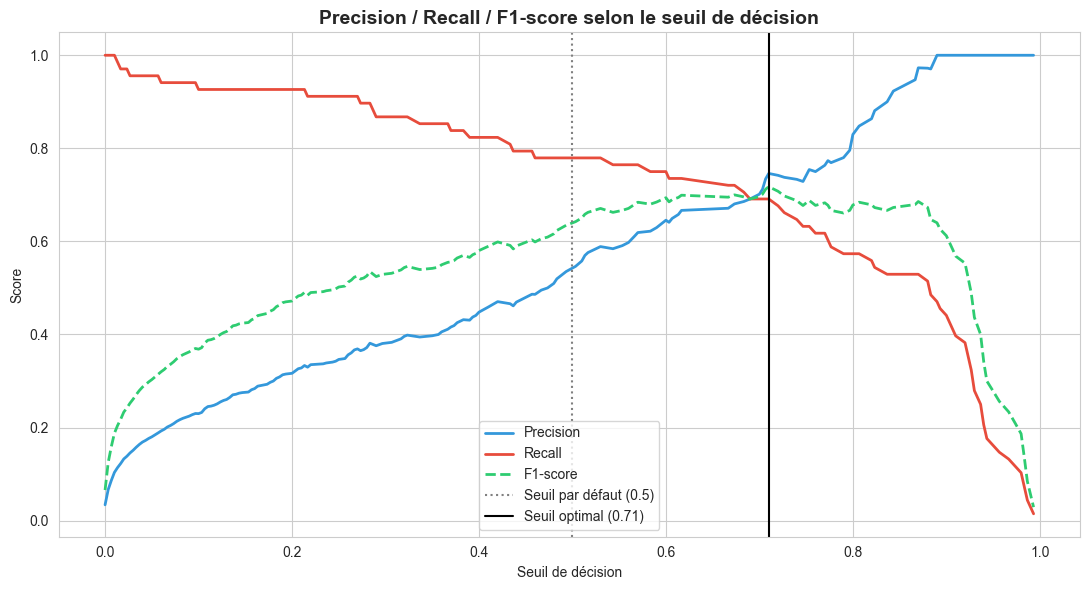

In [35]:
plt.figure(figsize=(11, 6))

plt.plot(seuils, precisions[:-1], label='Precision', linewidth=2, color='#3498db')
plt.plot(seuils, recalls[:-1], label='Recall', linewidth=2, color='#e74c3c')
plt.plot(seuils, f1_scores[:-1], label='F1-score', linewidth=2, color='#2ecc71', linestyle='--')

plt.axvline(0.5, color='gray', linestyle=':', label='Seuil par défaut (0.5)')
plt.axvline(meilleur_seuil, color='black', linestyle='-', linewidth=1.5, 
            label=f'Seuil optimal ({meilleur_seuil:.2f})')

plt.xlabel("Seuil de décision")
plt.ylabel("Score")
plt.title("Precision / Recall / F1-score selon le seuil de décision", fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig("../docs/optimisation_seuil.png", dpi=150, bbox_inches='tight')
plt.show()

## Application du seuil optimal et nouveau rapport

In [36]:
# On applique le seuil optimal au lieu du 0.5 par défaut
y_pred_seuil_optimal = (y_proba_final >= meilleur_seuil).astype(int)

print(f"=== Rapport avec seuil optimal ({meilleur_seuil:.3f}) ===")
print(classification_report(y_test, y_pred_seuil_optimal, target_names=['Normal', 'Panne']))

print(f"\n=== Comparaison ===")
print(f"Seuil 0.5 (défaut)     : Precision={precision_score(y_test, y_pred_final):.3f} | Recall={recall_score(y_test, y_pred_final):.3f} | F1={f1_score(y_test, y_pred_final):.3f}")
print(f"Seuil {meilleur_seuil:.3f} (optimal) : Precision={precision_score(y_test, y_pred_seuil_optimal):.3f} | Recall={recall_score(y_test, y_pred_seuil_optimal):.3f} | F1={f1_score(y_test, y_pred_seuil_optimal):.3f}")

=== Rapport avec seuil optimal (0.710) ===
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1932
       Panne       0.75      0.69      0.72        68

    accuracy                           0.98      2000
   macro avg       0.87      0.84      0.85      2000
weighted avg       0.98      0.98      0.98      2000


=== Comparaison ===
Seuil 0.5 (défaut)     : Precision=0.546 | Recall=0.779 | F1=0.642
Seuil 0.710 (optimal) : Precision=0.746 | Recall=0.691 | F1=0.718


## Sauvegarde de la configuration du seuil optimal

In [37]:
# On sauvegarde le seuil optimal pour l'utiliser plus tard dans l'API Flask
# (par défaut un modèle utilise 0.5, il faut donc retenir ce choix quelque part)

import json

config_modele = {
    "seuil_decision": float(meilleur_seuil),
    "modele": "Random Forest",
    "parametres": grid_search.best_params_,
    "performance": {
        "precision": float(precision_score(y_test, y_pred_seuil_optimal)),
        "recall": float(recall_score(y_test, y_pred_seuil_optimal)),
        "f1_score": float(f1_score(y_test, y_pred_seuil_optimal))
    }
}

with open("../model/config_modele.json", "w") as f:
    json.dump(config_modele, f, indent=4)

print("Configuration sauvegardée dans model/config_modele.json")
print(config_modele)

Configuration sauvegardée dans model/config_modele.json
{'seuil_decision': 0.71, 'modele': 'Random Forest', 'parametres': {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}, 'performance': {'precision': 0.746031746031746, 'recall': 0.6911764705882353, 'f1_score': 0.7175572519083969}}


## Matrice de confusion finale

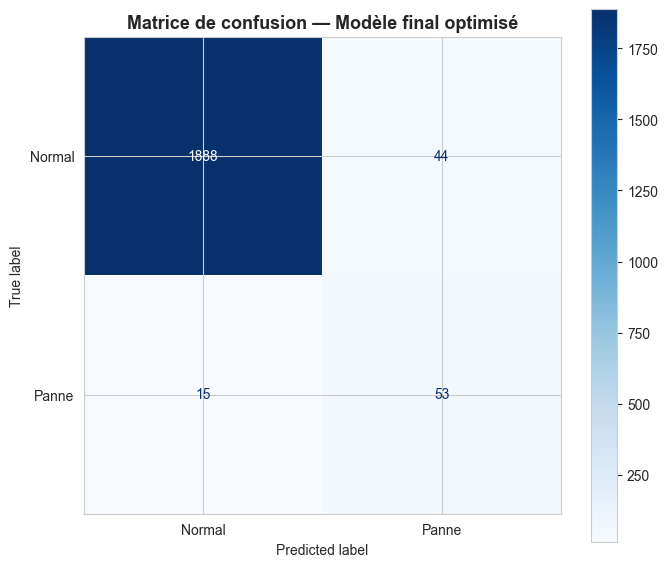

In [38]:
plt.figure(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Panne'])
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title("Matrice de confusion — Modèle final optimisé", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../docs/matrice_confusion_finale.png", dpi=150, bbox_inches='tight')
plt.show()

## Importance des variables (modèle final)

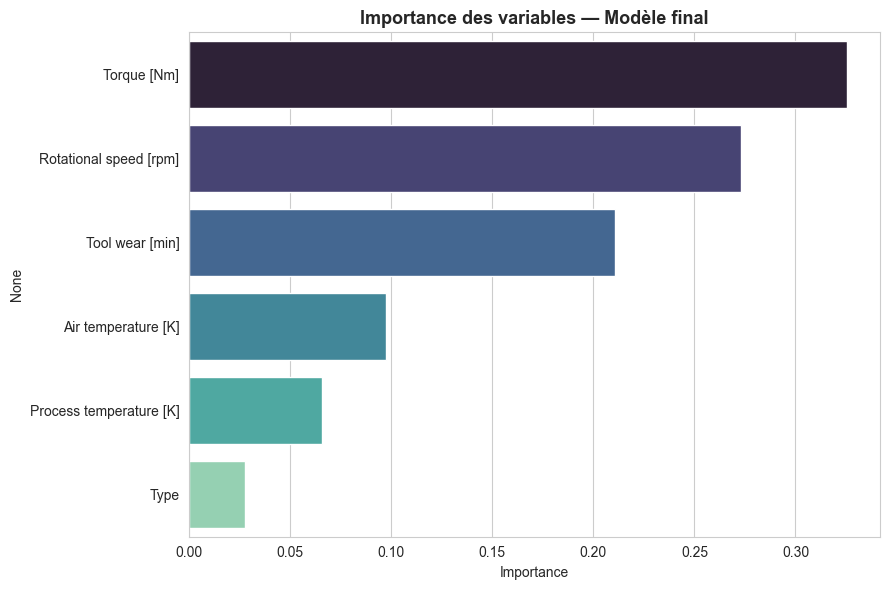

In [39]:
importances = pd.Series(meilleur_modele.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, palette='mako')
plt.title("Importance des variables — Modèle final", fontsize=13, fontweight='bold')
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../docs/importance_finale.png", dpi=150, bbox_inches='tight')
plt.show()

## Validation croisée du modèle final (robustesse)

Scores F1 sur 5 folds : [0.98159509 0.98715478 0.97960484 0.98521851 0.98395379]
Moyenne : 0.9835 (+/- 0.0027)


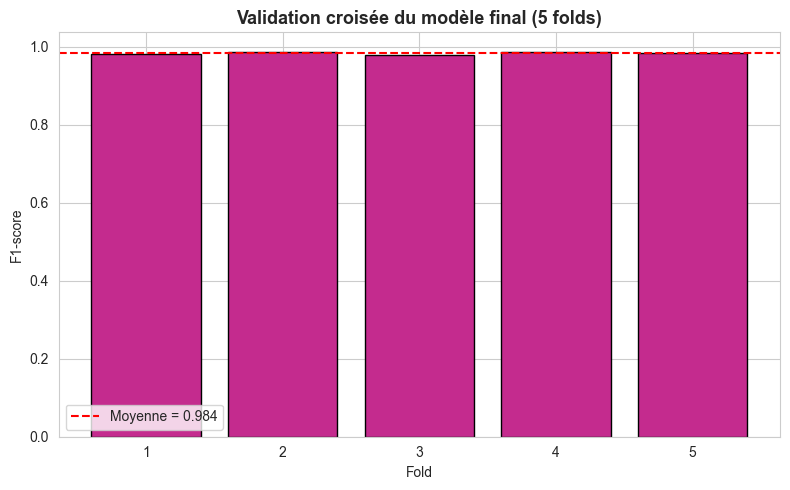

In [43]:
# On vérifie que le modèle n'a pas juste "eu de la chance" sur ce split précis
scores_cv = cross_val_score(meilleur_modele, X_train_smote, y_train_smote, 
                              cv=StratifiedKFold(n_splits=5), scoring='f1')

print(f"Scores F1 sur 5 folds : {scores_cv}")
print(f"Moyenne : {scores_cv.mean():.4f} (+/- {scores_cv.std():.4f})")

plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), scores_cv, color="#c42b8e", edgecolor='black')
plt.axhline(scores_cv.mean(), color='red', linestyle='--', label=f'Moyenne = {scores_cv.mean():.3f}')
plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("Validation croisée du modèle final (5 folds)", fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig("../docs/validation_croisee.png", dpi=150, bbox_inches='tight')
plt.show()

## Sauvegarde finale (modèle + scaler + encodeur)

In [47]:
joblib.dump(meilleur_modele, "../model/modele_entraine.pkl")
joblib.dump(scaler, "../model/scaler.pkl")
joblib.dump(encodeur_type, "../model/encodeur_type.pkl")

print("Modèle final, scaler et encodeur sauvegardés dans model/")
print(f"\nRécapitulatif final :")
print(f"- Modèle : Random Forest optimisé")
print(f"- Meilleurs paramètres : {grid_search.best_params_}")
print(f"- Recall (Panne) : {recall_score(y_test, y_pred_final):.3f}")
print(f"- Precision (Panne) : {precision_score(y_test, y_pred_final):.3f}")
print(f"- F1-score (Panne) : {f1_score(y_test, y_pred_final):.3f}")

Modèle final, scaler et encodeur sauvegardés dans model/

Récapitulatif final :
- Modèle : Random Forest optimisé
- Meilleurs paramètres : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
- Recall (Panne) : 0.779
- Precision (Panne) : 0.546
- F1-score (Panne) : 0.642


## Test du modèle sur des cas concrets

In [42]:
def predire_panne(air_temp, process_temp, rotation_speed, torque, tool_wear, type_produit='M'):
    """
    Simule ce que fera l'API Flask : reçoit des valeurs de capteurs,
    retourne si la machine risque de tomber en panne.
    """
    # Encodage du type de produit (comme à l'entraînement)
    type_encode = encodeur_type.transform([type_produit])[0]
    
    # Construction du vecteur de features (même ordre que X)
    donnees = np.array([[type_encode, air_temp, process_temp, rotation_speed, torque, tool_wear]])
    
    # Normalisation avec le même scaler que l'entraînement
    donnees_scaled = scaler.transform(donnees)
    
    # Probabilité de panne
    proba = meilleur_modele.predict_proba(donnees_scaled)[0][1]
    
    # Application du seuil optimal (0.71), pas le 0.5 par défaut
    panne_predite = proba >= meilleur_seuil
    
    return {
        "probabilite_panne": round(float(proba), 3),
        "panne_predite": bool(panne_predite),
        "seuil_utilise": meilleur_seuil
    }


# --- Test 1 : cas normal (valeurs "tranquilles") ---
print("=== Test 1 : Machine en fonctionnement normal ===")
print(predire_panne(air_temp=298.0, process_temp=308.5, rotation_speed=1500, 
                     torque=40, tool_wear=10, type_produit='M'))

# --- Test 2 : cas à risque (couple élevé + usure importante, d'après l'importance des variables) ---
print("\n=== Test 2 : Machine à risque (couple élevé + usure élevée) ===")
print(predire_panne(air_temp=302.0, process_temp=311.0, rotation_speed=1350, 
                     torque=65, tool_wear=220, type_produit='L'))

# --- Test 3 : cas extrême ---
print("\n=== Test 3 : Cas extrême ===")
print(predire_panne(air_temp=304.0, process_temp=313.0, rotation_speed=1200, 
                     torque=75, tool_wear=250, type_produit='L'))

=== Test 1 : Machine en fonctionnement normal ===
{'probabilite_panne': 0.0, 'panne_predite': False, 'seuil_utilise': np.float64(0.71)}

=== Test 2 : Machine à risque (couple élevé + usure élevée) ===
{'probabilite_panne': 0.95, 'panne_predite': True, 'seuil_utilise': np.float64(0.71)}

=== Test 3 : Cas extrême ===
{'probabilite_panne': 0.857, 'panne_predite': True, 'seuil_utilise': np.float64(0.71)}


## Vérification des fichiers sauvegardés

In [46]:
import os
print(os.listdir("../model"))

['.gitkeep', 'config_modele.json', 'encodeur_type.pkl', 'modele_entraine.pkl', 'scaler.pkl']
